In [1]:
import pandas as pd
import re
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from spacy import displacy, tokenizer
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
from gensim.models import LsiModel, TfidfModel
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from pathlib import Path


In [2]:
parent_dir = Path.cwd().parent

In [3]:
data = pd.read_csv(parent_dir.joinpath("Supporting_Docs").joinpath("fake_news_data.csv"))

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


Text(0.5, 1.0, 'Count of aricle classification')

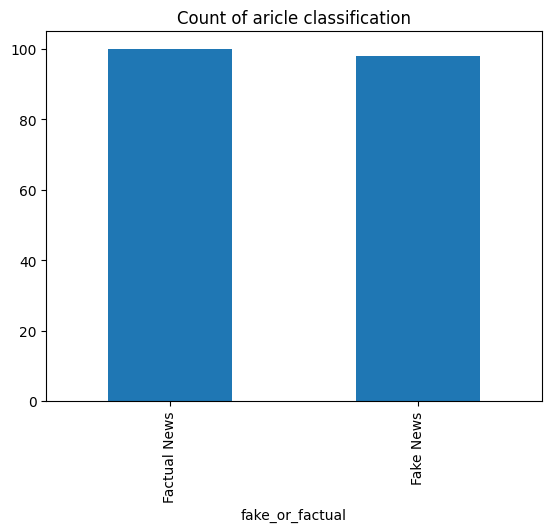

In [5]:
data['fake_or_factual'].value_counts().plot(kind='bar')
plt.title("Count of aricle classification")

POS Tagging

In [6]:
nlp = spacy.load('en_core_web_sm')

In [7]:
fake_news = data[data['fake_or_factual'] == 'Fake News']
factual_news = data[data['fake_or_factual'] == 'Factual News']

In [8]:
fake_spacy_docs = list(nlp.pipe(fake_news['text']))
factual_spacy_docs = list(nlp.pipe(factual_news['text']))

nlp.pipe() creates an easy way to inject the array and do the same fuction on each item of array which generates the output. List then capures it and storpes in a list format

In [9]:
def extract_token_tags(doc:spacy.tokens.doc.Doc):
    return[(item.text, item.ent_type_, item.pos_) for item in doc]

In [10]:
columns = ["token","ner_tag","pos_tag"]
faketag_df = pd.DataFrame(columns=columns)

In [11]:
for i, doc in enumerate(fake_spacy_docs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    faketag_df = pd.concat([faketag_df,tags])

In [12]:
factualtag_df = pd.DataFrame(columns=columns)

In [13]:
for i, doc in enumerate(factual_spacy_docs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    factualtag_df = pd.concat([factualtag_df,tags])

In [14]:
factualtag_df

,token,ner_tag,pos_tag
0,WASHINGTON,GPE,PROPN
1,(,,PUNCT
2,Reuters,ORG,PROPN
3,),,PUNCT
4,-,,PUNCT
...,...,...,...
85,citing,,VERB
86,three,CARDINAL,NUM
87,unnamed,,ADJ
88,officials,,NOUN


Next i am counting the same token and Parts of speech tag in the entire fake and factual data.

In [15]:
pos_count_fake = faketag_df.groupby(['token','pos_tag']).size().reset_index(name='count').sort_values(by='count', ascending=False)
pos_count_fake
#.size()

,token,pos_tag,count
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
...,...,...,...
3770,detectives,VERB,1
3769,detective,NOUN,1
3768,detained,VERB,1
3766,detail,NOUN,1


In [16]:
pos_count_factual = factualtag_df.groupby(['token','pos_tag']).size().reset_index(name='count').sort_values(by='count', ascending=False)
pos_count_factual

,token,pos_tag,count
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
...,...,...,...
2909,crossing,VERB,1
2911,crucial,ADJ,1
2913,cruise,NOUN,1
2914,crusade,NOUN,1


I observe that both have mostly the similar kind of frequently occuring combo and so i decided now to check if certain parts of speech is occuring more in fake data

In [17]:
pos_count_fake.groupby('pos_tag')['token'].size().sort_values(ascending=False)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
DET        42
INTJ       24
PUNCT      23
CCONJ      19
X          14
PART       10
SYM         5
SPACE       3
Name: token, dtype: int64

In [18]:
pos_count_factual.groupby('pos_tag')['token'].size().sort_values(ascending=False)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
DET        36
PUNCT      22
SPACE      11
CCONJ      11
X          10
INTJ        7
PART        7
SYM         4
Name: token, dtype: int64

Again it was observed tha sanme NOUN VERB PROPN are the order. so I will deep dive into Noun specificity

In [19]:
pos_count_fake[pos_count_fake['pos_tag']=="NOUN"]

,token,pos_tag,count
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
...,...,...,...
3781,developments,NOUN,1
3778,devastation,NOUN,1
3772,determination,NOUN,1
3769,detective,NOUN,1


In [20]:
pos_count_factual[pos_count_factual['pos_tag']=="NOUN"]

,token,pos_tag,count
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
...,...,...,...
2905,cross,NOUN,1
2907,crosses,NOUN,1
2908,crossing,NOUN,1
2913,cruise,NOUN,1


NAMED ENTITIES

In [21]:
names_entities_fake = faketag_df[faketag_df['ner_tag'] != ""].groupby(['token','ner_tag']).size().reset_index(name='count').sort_values(by='count',ascending=False)
names_entities_fake

,token,ner_tag,count
1730,Trump,PERSON,154
1729,Trump,ORG,152
2129,the,ORG,121
592,Clinton,PERSON,118
718,Donald,PERSON,75
...,...,...,...
886,Hempstead,GPE,1
885,Helbig,PERSON,1
884,Hedge,PERSON,1
883,Heather,PERSON,1


In [22]:
names_entities_factual = factualtag_df[factualtag_df['ner_tag'] != ""].groupby(['token','ner_tag']).size().reset_index(name='count').sort_values(by='count',ascending=False)
names_entities_factual

,token,ner_tag,count
1968,the,ORG,159
1633,U.S.,GPE,138
1373,Reuters,ORG,131
1615,Trump,PERSON,125
1614,Trump,ORG,124
...,...,...,...
804,German,NORP,1
803,Georgia,GPE,1
801,George,ORG,1
800,Geological,ORG,1


In [23]:
ner_pallete = {
    'ORG' : sns.color_palette('Set2').as_hex()[0],
    'PERSON' : sns.color_palette('Set2').as_hex()[1],
    'GPE' : sns.color_palette('Set2').as_hex()[2],
    'DATE' : sns.color_palette('Set2').as_hex()[3],
    'NORP' : sns.color_palette('Set2').as_hex()[4],
    'CARDINAL' : sns.color_palette('Set2').as_hex()[5],
    'PERCENT' : sns.color_palette('Set2').as_hex()[6],
}

[Text(0.5, 1.0, 'Most common Names Entity in Fake News')]

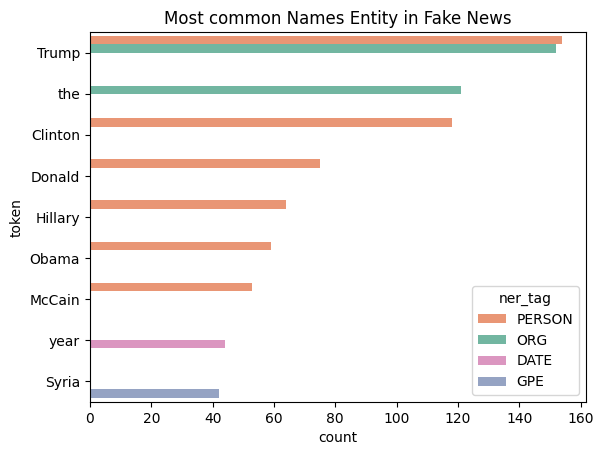

In [24]:
sns.barplot(
    x = 'count',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_pallete,
    data = names_entities_fake[:10],
    orient = 'h',
    dodge = True
).set(title = "Most common Names Entity in Fake News")

[Text(0.5, 1.0, 'Most common Names Entity in Factual News')]

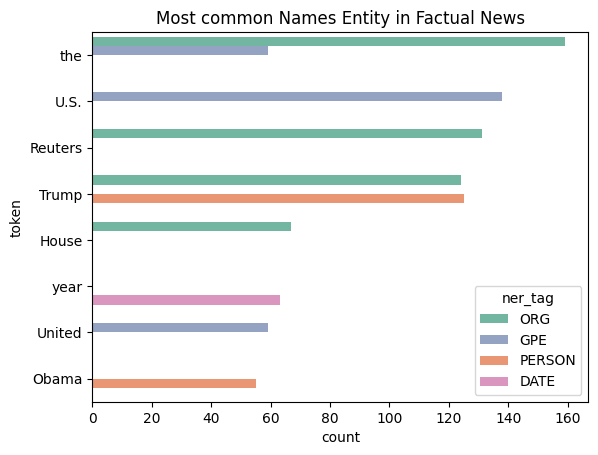

In [25]:
sns.barplot(
    x = 'count',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_pallete,
    data = names_entities_factual[:10],
    orient = 'h',
    dodge = True
).set(title = "Most common Names Entity in Factual News")

TEXT PREPROCESSING

In [26]:
data

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News
...,...,...,...,...
193,AND SO IT BEGINS…INSPIRED BY GAY MARRIAGE RULI...,"Well, that didn t take long. Look for the firs...","Jul 2, 2015",Fake News
194,‘Stand Your Ground’: FL Man Shoots At Teens P...,Florida s toxic and dangerous stand your grou...,"July 17, 2016",Fake News
195,The Los Angeles Times Endorses Hillary Clinto...,As Politico reports an almost neck-and-neck ra...,"May 30, 2016",Fake News
196,FBI chief sought more funds for Russia probe d...,WASHINGTON (Reuters) - Former FBI Director Jam...,"May 10, 2017",Factual News


In [27]:
#removing the location tag
data['clean_text'] = data.apply(lambda x : re.sub(r"^[^-]*-\s","",x['text']), axis=1)

In [28]:
# Converting the text into lower case
data['clean_text'] = data['clean_text'].str.lower()

In [29]:
# remove puntuations
data['clean_text'] = data.apply(lambda x : re.sub(r"([^\w\s])","",x['clean_text']), axis=1)

In [30]:
# removing stopwords
en_stopwords = stopwords.words('english')
data['clean_text'] = data.apply(lambda x : " ".join([word for word in x['clean_text'].split(" ") if word not in en_stopwords]), axis=1)

In [31]:
# tokenize
data['clean_text'] = data.apply(lambda x : word_tokenize(x['clean_text']), axis=1)

In [32]:
# lemmatize
wnl = WordNetLemmatizer()
data['clean_text'] = data['clean_text'].apply( lambda x : [wnl.lemmatize(token) for token in x])

In [33]:
data

,title,text,date,fake_or_factual,clean_text
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."
...,...,...,...,...,...
193,AND SO IT BEGINS…INSPIRED BY GAY MARRIAGE RULI...,"Well, that didn t take long. Look for the firs...","Jul 2, 2015",Fake News,"[well, take, long, look, first, beastiality, m..."
194,‘Stand Your Ground’: FL Man Shoots At Teens P...,Florida s toxic and dangerous stand your grou...,"July 17, 2016",Fake News,"[florida, toxic, dangerous, stand, ground, gun..."
195,The Los Angeles Times Endorses Hillary Clinto...,As Politico reports an almost neck-and-neck ra...,"May 30, 2016",Fake News,"[politico, report, almost, neckandneck, race, ..."
196,FBI chief sought more funds for Russia probe d...,WASHINGTON (Reuters) - Former FBI Director Jam...,"May 10, 2017",Factual News,"[former, fbi, director, james, comey, requeste..."


[Text(0.5, 1.0, 'Most common unigram after preprocessing')]

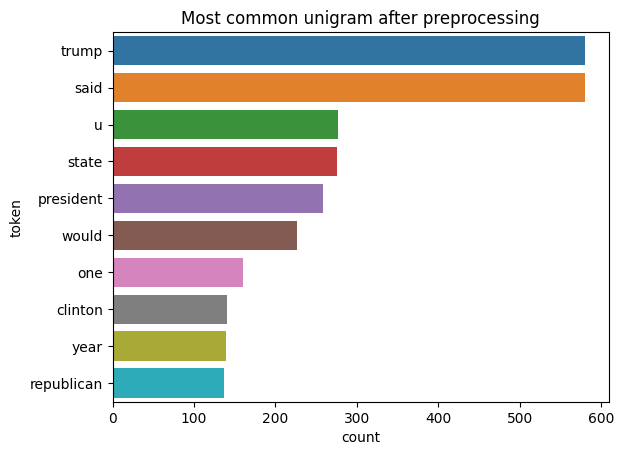

In [37]:
token_clean = sum(data['clean_text'], [])
unigram = pd.Series(nltk.ngrams(token_clean,1)).value_counts().reset_index()
unigram["token"] = unigram['index'].apply(lambda x : x[0])
sns.barplot(
    x="count",
    y="token",
    data=unigram[:10],
    orient="h",
    hue="token",
    legend=False
).set(title = "Most common unigram after preprocessing")


[Text(0.5, 1.0, 'Most common bigrams after preprocessing')]

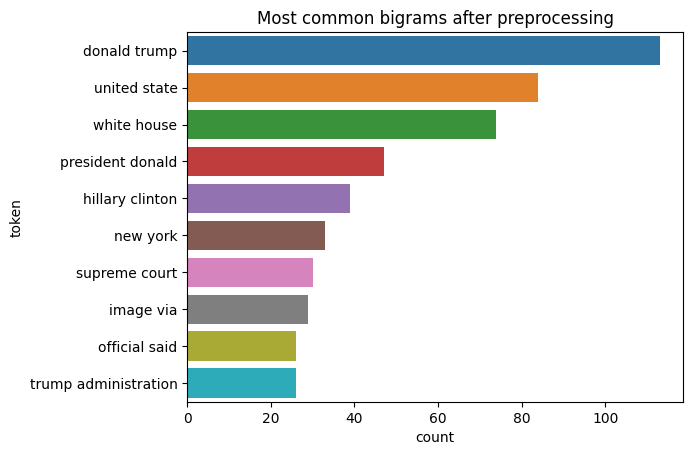

In [42]:
bigrams = pd.Series(nltk.ngrams(token_clean,2)).value_counts().reset_index()
bigrams["token"] = bigrams['index'].apply(lambda x : " ".join(x[0:2]))
sns.barplot(
    x="count",
    y="token",
    data=bigrams[:10],
    orient="h",
    hue="token",
    legend=False
).set(title = "Most common bigrams after preprocessing")

[Text(0.5, 1.0, 'Most common trigrams after preprocessing')]

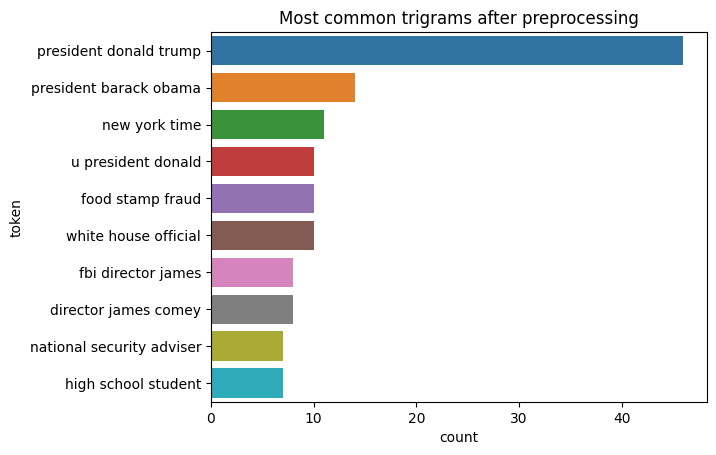

In [43]:
trigrams = pd.Series(nltk.ngrams(token_clean,3)).value_counts().reset_index()
trigrams["token"] = trigrams['index'].apply(lambda x : " ".join(x[0:3]))
sns.barplot(
    x="count",
    y="token",
    data=trigrams[:10],
    orient="h",
    hue="token",
    legend=False
).set(title = "Most common trigrams after preprocessing")

[Text(0.5, 1.0, 'Most common quadgrams after preprocessing')]

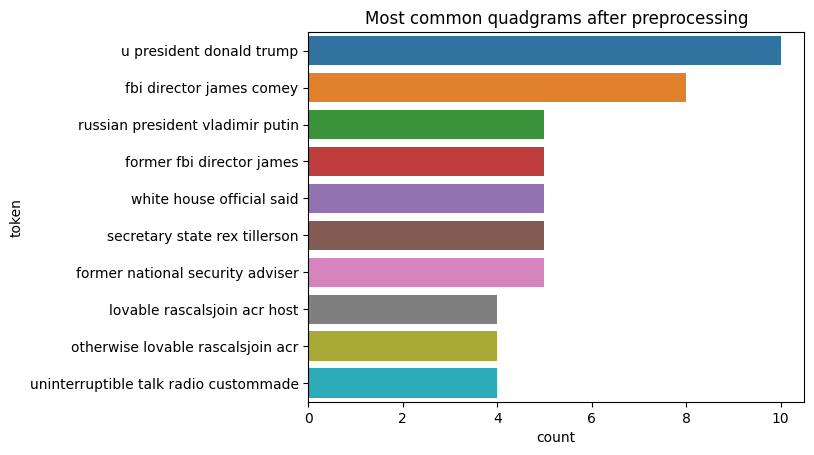

In [44]:
quadgrams = pd.Series(nltk.ngrams(token_clean,4)).value_counts().reset_index()
quadgrams["token"] = quadgrams['index'].apply(lambda x : " ".join(x[0:4]))
sns.barplot(
    x="count",
    y="token",
    data=quadgrams[:10],
    orient="h",
    hue="token",
    legend=False
).set(title = "Most common quadgrams after preprocessing")

[Text(0.5, 1.0, 'Most common pentagrams after preprocessing')]

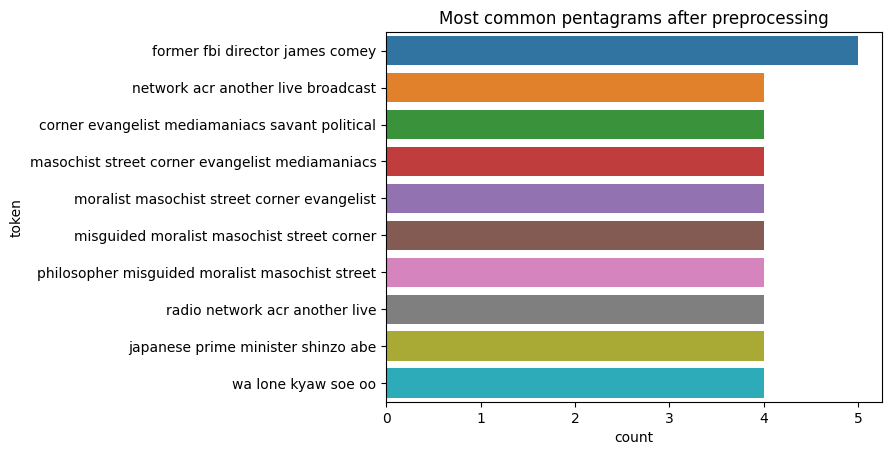

In [45]:
pentagrams = pd.Series(nltk.ngrams(token_clean,5)).value_counts().reset_index()
pentagrams["token"] = pentagrams['index'].apply(lambda x : " ".join(x[0:5]))
sns.barplot(
    x="count",
    y="token",
    data=pentagrams[:10],
    orient="h",
    hue="token",
    legend=False
).set(title = "Most common pentagrams after preprocessing")

Sentiment Analysis

In [47]:
vader_sentiment = SentimentIntensityAnalyzer()

In [51]:
data['vader_sentimeint_score'] = data['text'].apply(lambda x: vader_sentiment.polarity_scores(x)['compound'])

In [53]:
bins = [-1, -.1, .1, 1]
label = ["Negetive", "Neutral", "Positive"]

data['vader_sentiment_label'] = pd.cut(data['vader_sentimeint_score'],bins=bins, labels=label)

<Axes: xlabel='vader_sentiment_label'>

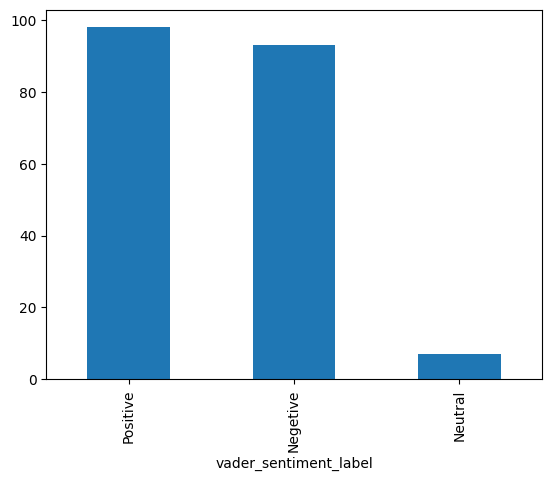

In [60]:
data['vader_sentiment_label'].value_counts().plot.bar()

[Text(0.5, 1.0, 'Sentiment Analysis of fake or factual per Sentiment')]

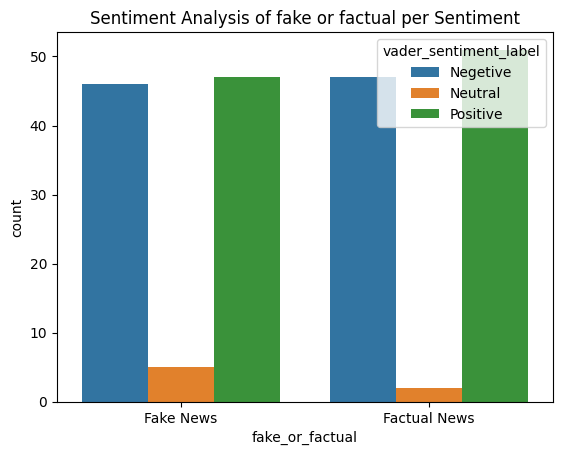

In [62]:
sns.countplot(
    data=data,
    x="fake_or_factual",
    hue = "vader_sentiment_label"
).set(title = "Sentiment Analysis of fake or factual per Sentiment")

TOPIC MODELLING

In [63]:
fake_news_text = data[data['fake_or_factual']=="Fake News"]['clean_text'].reset_index(drop=True)

In [65]:
dictionary_fake = corpora.Dictionary(fake_news_text)
doc_term_fake = [dictionary_fake.doc2bow(text) for text in fake_news_text]

In [67]:
coherence_value = []
for i in range(2,15):
    model = gensim.models.LdaModel(doc_term_fake, num_topics=i, id2word=dictionary_fake)
    coherence_model = CoherenceModel(model=model,texts=fake_news_text,dictionary=dictionary_fake,coherence='c_v')
    coherence_value.append(coherence_model.get_coherence())

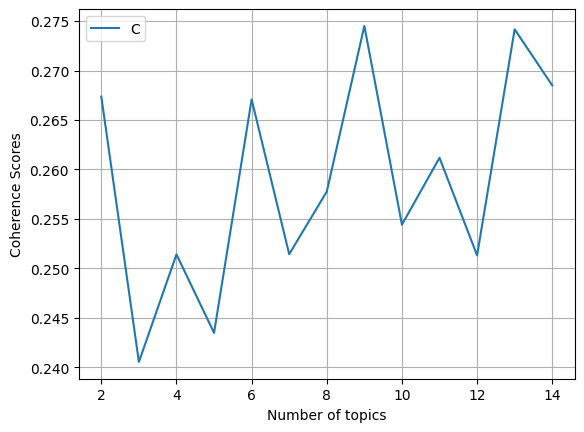

In [68]:
plt.plot(range(2,15),coherence_value)
plt.xlabel("Number of topics")
plt.ylabel("Coherence Scores")
plt.grid()
plt.legend(("Coherence Values"), loc = "best")
plt.show()

In [70]:
LDA_model = gensim.models.LdaModel(doc_term_fake, num_topics=9, id2word=dictionary_fake)
LDA_model.print_topics(num_topics = 9, num_words=10)

[(0,
  '0.008*"trump" + 0.005*"president" + 0.004*"one" + 0.004*"clinton" + 0.004*"obama" + 0.004*"republican" + 0.003*"u" + 0.003*"like" + 0.003*"said" + 0.003*"would"'),
 (1,
  '0.005*"trump" + 0.005*"state" + 0.005*"said" + 0.005*"hillary" + 0.004*"president" + 0.004*"clinton" + 0.004*"would" + 0.003*"one" + 0.003*"people" + 0.003*"u"'),
 (2,
  '0.022*"trump" + 0.005*"said" + 0.005*"donald" + 0.004*"would" + 0.004*"president" + 0.004*"time" + 0.004*"clinton" + 0.004*"u" + 0.004*"people" + 0.003*"one"'),
 (3,
  '0.012*"trump" + 0.006*"president" + 0.004*"u" + 0.004*"state" + 0.004*"time" + 0.004*"said" + 0.003*"obama" + 0.003*"one" + 0.003*"people" + 0.003*"year"'),
 (4,
  '0.009*"trump" + 0.005*"clinton" + 0.005*"woman" + 0.004*"student" + 0.003*"state" + 0.003*"said" + 0.003*"would" + 0.003*"president" + 0.002*"also" + 0.002*"one"'),
 (5,
  '0.007*"said" + 0.005*"state" + 0.005*"trump" + 0.004*"email" + 0.004*"u" + 0.003*"would" + 0.003*"record" + 0.003*"clinton" + 0.003*"official"

In [71]:
data

,title,text,date,fake_or_factual,clean_text,vader_sentimeint_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,Negetive
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,Negetive
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,Positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,Negetive
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,Positive
...,...,...,...,...,...,...,...
193,AND SO IT BEGINS…INSPIRED BY GAY MARRIAGE RULI...,"Well, that didn t take long. Look for the firs...","Jul 2, 2015",Fake News,"[well, take, long, look, first, beastiality, m...",0.9001,Positive
194,‘Stand Your Ground’: FL Man Shoots At Teens P...,Florida s toxic and dangerous stand your grou...,"July 17, 2016",Fake News,"[florida, toxic, dangerous, stand, ground, gun...",-0.9946,Negetive
195,The Los Angeles Times Endorses Hillary Clinto...,As Politico reports an almost neck-and-neck ra...,"May 30, 2016",Fake News,"[politico, report, almost, neckandneck, race, ...",0.9958,Positive
196,FBI chief sought more funds for Russia probe d...,WASHINGTON (Reuters) - Former FBI Director Jam...,"May 10, 2017",Factual News,"[former, fbi, director, james, comey, requeste...",-0.5719,Negetive


Costum Classifier for Fake or Factual News

In [72]:
data['clean_text_appended'] = data.apply(lambda x : " ".join([word for word in x['clean_text']]), axis=1)

In [73]:
data

,title,text,date,fake_or_factual,clean_text,vader_sentimeint_score,vader_sentiment_label,clean_text_appended
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,Negetive,two small problem analogy susan jesus muslim j...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,Negetive,buried trump bonkers interview new york time r...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,Positive,woman make 50 percent country grossly underrep...
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,Negetive,u defense secretary jim mattis said monday rus...
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,Positive,northern ireland political party rapidly runni...
...,...,...,...,...,...,...,...,...
193,AND SO IT BEGINS…INSPIRED BY GAY MARRIAGE RULI...,"Well, that didn t take long. Look for the firs...","Jul 2, 2015",Fake News,"[well, take, long, look, first, beastiality, m...",0.9001,Positive,well take long look first beastiality marriage...
194,‘Stand Your Ground’: FL Man Shoots At Teens P...,Florida s toxic and dangerous stand your grou...,"July 17, 2016",Fake News,"[florida, toxic, dangerous, stand, ground, gun...",-0.9946,Negetive,florida toxic dangerous stand ground gun cultu...
195,The Los Angeles Times Endorses Hillary Clinto...,As Politico reports an almost neck-and-neck ra...,"May 30, 2016",Fake News,"[politico, report, almost, neckandneck, race, ...",0.9958,Positive,politico report almost neckandneck race hillar...
196,FBI chief sought more funds for Russia probe d...,WASHINGTON (Reuters) - Former FBI Director Jam...,"May 10, 2017",Factual News,"[former, fbi, director, james, comey, requeste...",-0.5719,Negetive,former fbi director james comey requested addi...


In [ ]:
x = data['clean_text_appended']
y = data['fake_or_factual']


In [93]:
TFIDF = TfidfVectorizer()
TFIDF_fit = TFIDF.fit_transform(x)
TFIDF_bag = pd.DataFrame(TFIDF_fit.toarray(),columns=TFIDF.get_feature_names_out())
x_train,x_test,y_train,y_test = train_test_split(TFIDF_bag,y,test_size=0.2, random_state=2)
lr = LogisticRegression(random_state=3).fit(x_train,y_train)
y_pred_lr = lr.predict(x_test)
accuracy_score(y_true=y_test,y_pred=y_pred_lr)

0.9

In [99]:
CountVEC = CountVectorizer()
CountVEC_fit = CountVEC.fit_transform(x)
CountVEC_bag = pd.DataFrame(CountVEC_fit.toarray(),columns=CountVEC.get_feature_names_out())
x2_train,x2_test,y2_train,y2_test = train_test_split(CountVEC_bag,y,test_size=0.2, random_state=4)
lr2 = LogisticRegression(random_state=4).fit(x2_train,y2_train)
y_pred_lr2 = lr2.predict(x2_test)
accuracy_score(y_true=y2_test,y_pred=y_pred_lr2)

0.95

In [103]:
TFIDF = TfidfVectorizer()
TFIDF_fit = TFIDF.fit_transform(x)
TFIDF_bag = pd.DataFrame(TFIDF_fit.toarray(),columns=TFIDF.get_feature_names_out())
x_train,x_test,y_train,y_test = train_test_split(TFIDF_bag,y,test_size=0.2, random_state=2)
lsvm = SGDClassifier(random_state=3).fit(x_train,y_train)
y_pred_lsvm = lsvm.predict(x_test)
accuracy_score(y_true=y_test,y_pred=y_pred_lr)

0.9

Changing the random state changes the behaviour of the accuracy